In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.linear_model import LinearRegression
#Import all needed libraries for project


In [65]:
df = pd.read_csv("marketing_campaigns.csv")
df['revenue_generated'] = df['revenue_generated'] / 1000000
df['campaign_cost'] = df['campaign_cost'] / 1000000
DirectApp = df[df['channel'] == 'Direct/App']
SocialMediaInstagram = df[df['channel'] == 'Social Media - Instagram']
OrganicSearch = df[df['channel'] == 'Organic Search']
SMSMarketing = df[df['channel'] == 'SMS Marketing']
EmailMarketing = df[df['channel'] == 'Email Marketing']
Referral = df[df['channel'] == 'Referral']
Affiliate = df[df['channel'] == 'Affiliate']
PaidSearch = df[df['channel'] == 'Paid Search']
SocialMediaFacebook = df[df['channel'] == 'Social Media - Facebook']
InfluencerMarketing = df[df['channel'] == 'Influencer Marketing']
#read csv file and create dataframes for each channel

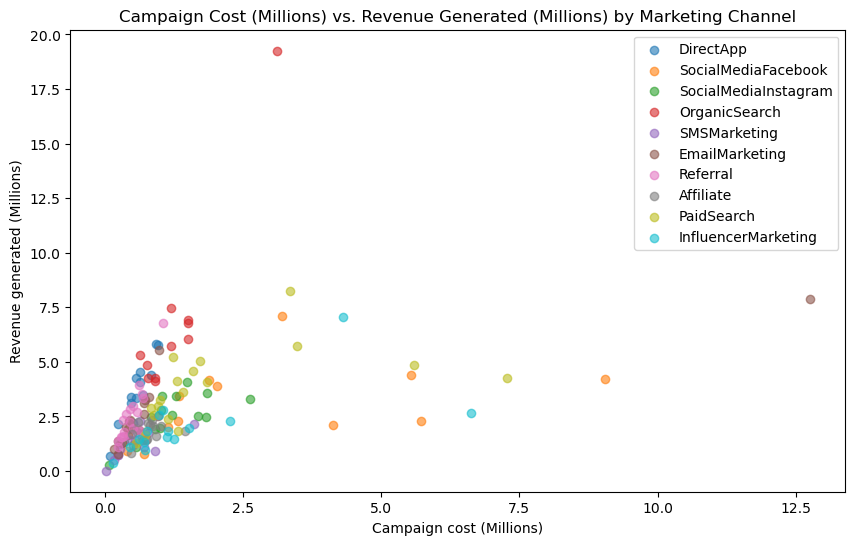

In [66]:
channels = {
    "DirectApp": DirectApp,
    "SocialMediaFacebook": SocialMediaFacebook,
    "SocialMediaInstagram": SocialMediaInstagram,
    "OrganicSearch": OrganicSearch,
    "SMSMarketing": SMSMarketing,
    "EmailMarketing": EmailMarketing,
    "Referral": Referral,
    "Affiliate": Affiliate,
    "PaidSearch": PaidSearch,
    "InfluencerMarketing": InfluencerMarketing
}

plt.figure(figsize=(10, 6))

for channel_name, data in channels.items():
    sample = data

    plt.scatter(
        sample["campaign_cost"],
        sample["revenue_generated"],
        alpha=0.6,
        label=channel_name
    )

plt.title("Campaign Cost (Millions) vs. Revenue Generated (Millions) by Marketing Channel")
plt.xlabel("Campaign cost (Millions)")
plt.ylabel("Revenue generated (Millions)")
plt.locator_params(axis="x", nbins=6)
plt.legend()
plt.show()
#Plot a scatter plot of campaign cost vs revenue generated for each marketing channel

DirectApp
Trendline: y = 6.09x + 0.00
R-squared: 0.859


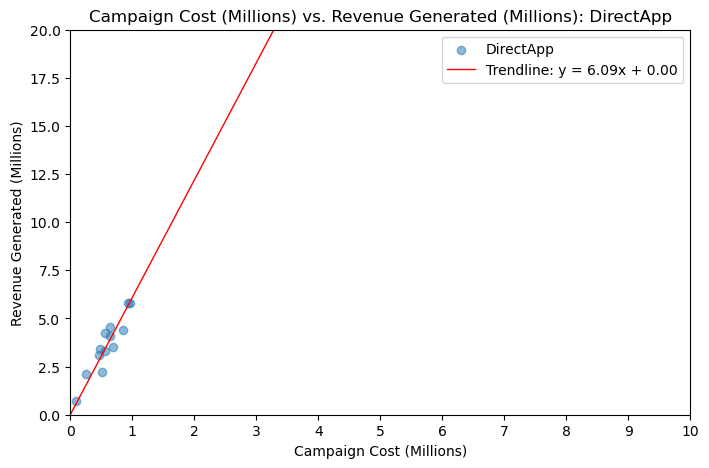

SocialMediaFacebook
Trendline: y = 0.73x + 0.00
R-squared: -0.533


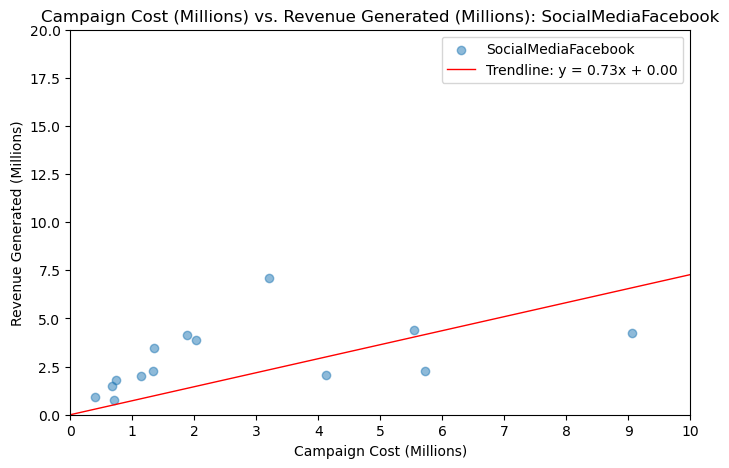

SocialMediaInstagram
Trendline: y = 1.89x + 0.00
R-squared: 0.261


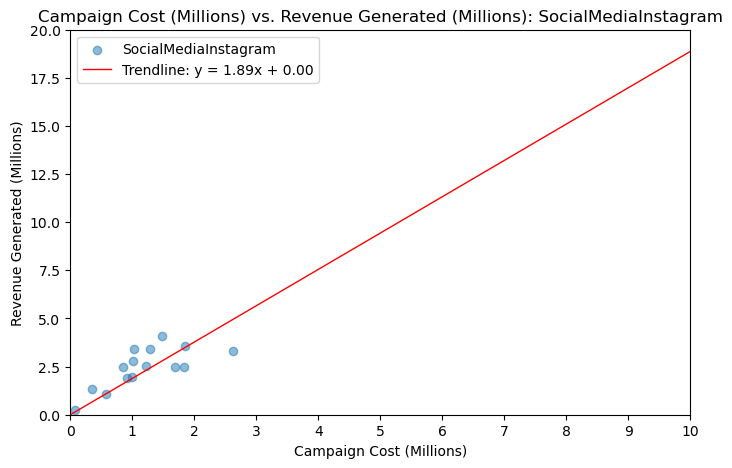

OrganicSearch
Trendline: y = 5.45x + 0.00
R-squared: 0.902


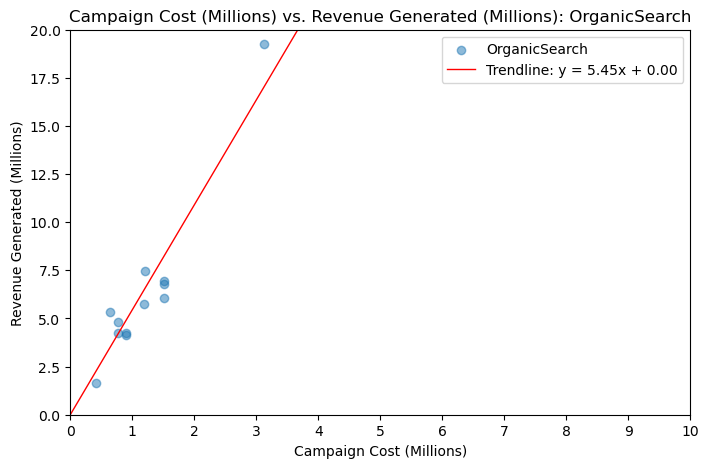

SMSMarketing
Trendline: y = 1.89x + 0.00
R-squared: 0.162


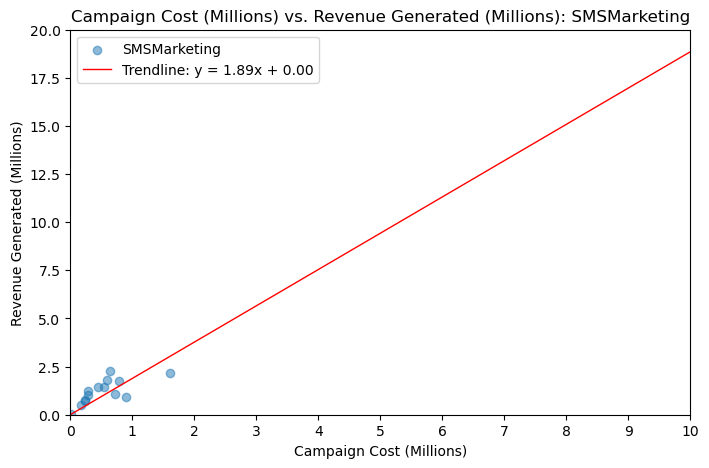

EmailMarketing
Trendline: y = 4.20x + 0.00
R-squared: 0.692


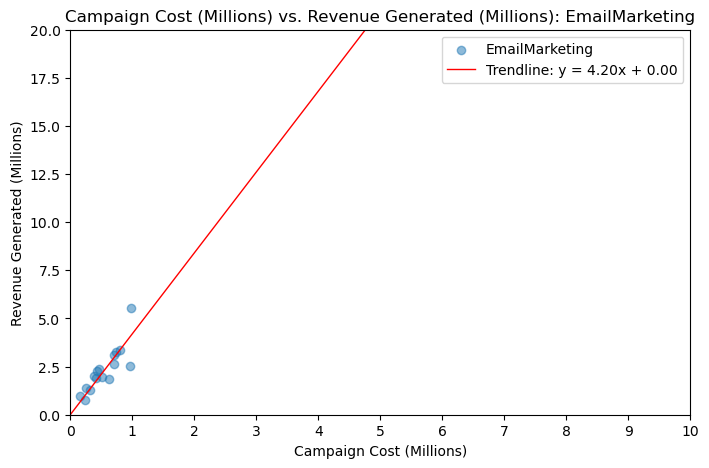

Referral
Trendline: y = 5.40x + 0.00
R-squared: 0.803


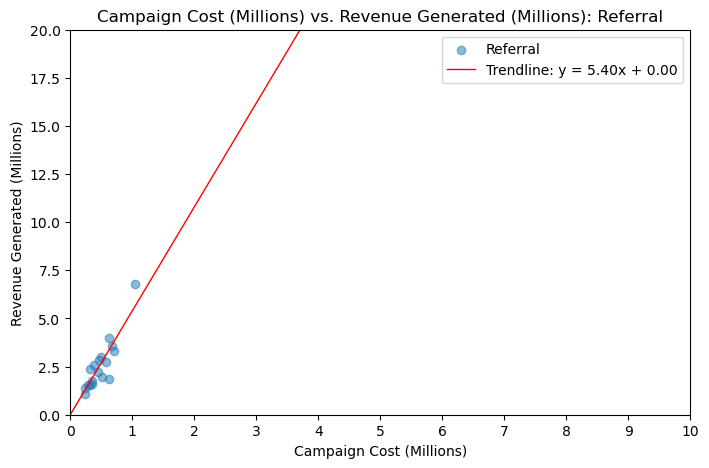

Affiliate
Trendline: y = 2.09x + 0.00
R-squared: -0.474


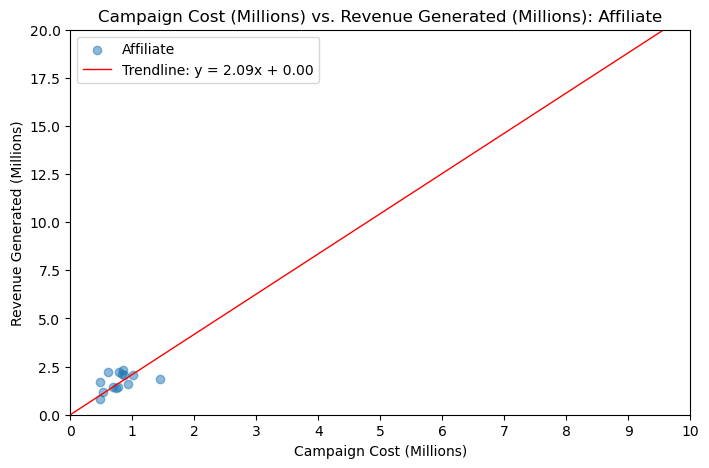

PaidSearch
Trendline: y = 1.75x + 0.00
R-squared: -0.221


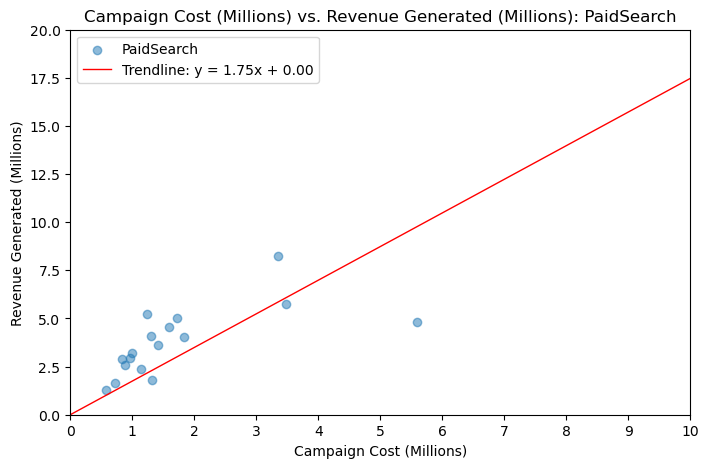

InfluencerMarketing
Trendline: y = 0.91x + 0.00
R-squared: 0.017


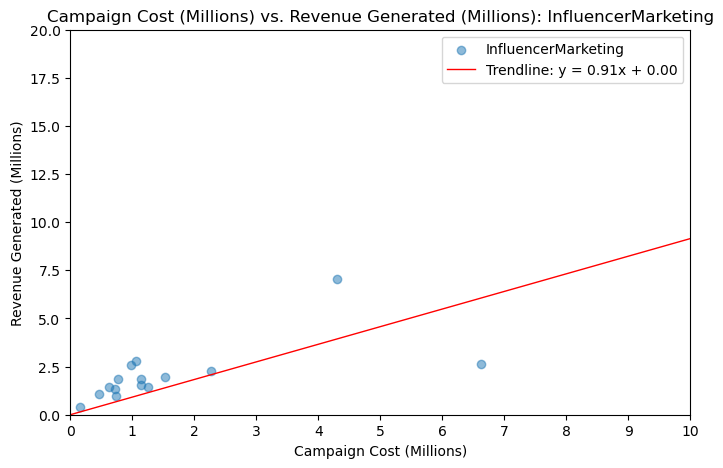

In [67]:
for channel_name, data in channels.items():

    # Keep only rows with valid values in both variables
    clean_data = data.dropna(
        subset=["campaign_cost", "revenue_generated"]
    ).query(
        "roi < roi.quantile(0.75) + (roi.quantile(0.75) - roi.quantile(0.25)) * 1.5"
    ).query(
        "roi > roi.quantile(0.25) - (roi.quantile(0.75) - roi.quantile(0.25)) * 1.5"
    )

    # Create and fit the regression model
    reg = LinearRegression(fit_intercept=False)
    reg.fit(
        clean_data[["campaign_cost"]],      # X must be 2D: double brackets
        clean_data["revenue_generated"]     # y can be 1D: single brackets
    )

    # Extract the equation components
    slope = reg.coef_[0]
    intercept = reg.intercept_
    r_squared = reg.score(
        clean_data[["campaign_cost"]],
        clean_data["revenue_generated"]
    )
    print(channel_name)
    print(f"Trendline: y = {slope:.2f}x + {intercept:.2f}")
    print(f"R-squared: {r_squared:.3f}")

    # Make evenly spaced cost values for a smooth trendline
    x_values = np.linspace(
        0,
        10,
        100
    )

    # predict() requires its input to be 2D
    x_values_df = pd.DataFrame({"campaign_cost": x_values})
    y_values = reg.predict(x_values_df)

    # Plot points
    plt.figure(figsize=(8, 5))

    plt.scatter(
        clean_data["campaign_cost"],
        clean_data["revenue_generated"],
        alpha=0.5,
        label=channel_name
    )

    # Plot LinearRegression trendline
    plt.plot(
        x_values,
        y_values,
        color="red",
        linewidth=1,
        label=f"Trendline: y = {slope:.2f}x + {intercept:.2f}"
    )

    plt.title(f"Campaign Cost (Millions) vs. Revenue Generated (Millions): {channel_name}")
    plt.xlabel("Campaign Cost (Millions)")
    plt.ylabel("Revenue Generated (Millions)")
    plt.locator_params(axis="x", nbins=10)
    plt.legend()
    plt.xlim(0, 10)
    plt.ylim(0, 20)
    plt.show()
#Plot and add trendlines for each marketing channel with their respective equations and R-squared values

DirectApp: Median ROI = 6.39
SocialMediaFacebook: Median ROI = 1.84
SocialMediaInstagram: Median ROI = 2.09
OrganicSearch: Median ROI = 4.75
SMSMarketing: Median ROI = 2.95
EmailMarketing: Median ROI = 4.40
Referral: Median ROI = 5.01
Affiliate: Median ROI = 2.16
PaidSearch: Median ROI = 2.52
InfluencerMarketing: Median ROI = 1.64


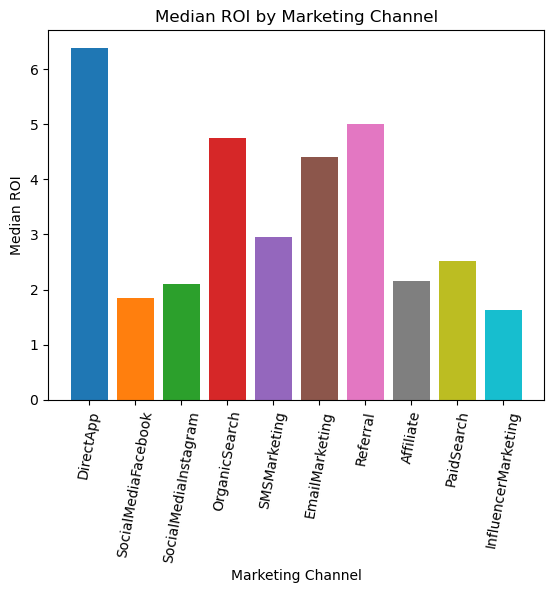

In [68]:
for channel_name, data in channels.items():
    roi = data["revenue_generated"] / data["campaign_cost"] if not data.empty else 0
    medianroi = roi.median() if not roi.empty else 0
    plt.bar(
        channel_name,
        medianroi,
        0.8,
    )
    print(f"{channel_name}: Median ROI = {medianroi:.2f}")

plt.title("Median ROI by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Median ROI")
plt.xticks(rotation=80)
plt.show()

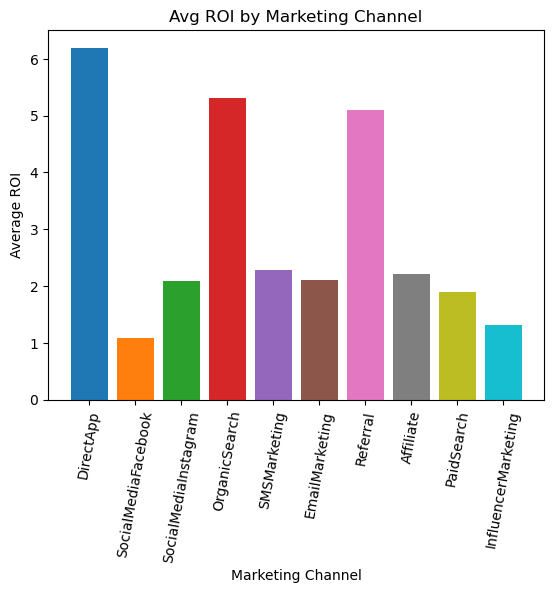

In [69]:
for channel_name, data in channels.items():
    avgroi = data["revenue_generated"].mean() / data["campaign_cost"].mean() if not data.empty else 0

    plt.bar(
        channel_name,
        avgroi,
        0.8,
    )

plt.title("Avg ROI by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average ROI")
plt.xticks(rotation=80)
plt.show()